# Workflow for a multi-regional energy system

In this application of the ETHOS.FINE framework, a multi-regional energy system is modeled and optimized.

All classes which are available to the user are utilized and examples of the selection of different parameters within these classes are given.

The workflow is structures as follows:
1. Required packages are imported and the input data path is set
2. An energy system model instance is created
3. Commodity sources are added to the energy system model
4. Commodity conversion components are added to the energy system model
5. Commodity storages are added to the energy system model
6. Commodity transmission components are added to the energy system model
7. Commodity sinks are added to the energy system model
8. The energy system model is optimized
9. Selected optimization results are presented


# 1. Import required packages and set input data path

The ETHOS.FINE framework is imported which provides the required classes and functions for modeling the energy system.

In [46]:
import fine as fn
from getData import getData
import pandas as pd
from pathlib import Path

cwd = Path.cwd()
data = getData()

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. Create an energy system model instance 

The structure of the energy system model is given by the considered locations, commodities, the number of time steps as well as the hours per time step.

The commodities are specified by a unit (i.e. 'GW_electric', 'GW_H2lowerHeatingValue', 'Mio. t CO2/h') which can be given as an energy or mass unit per hour. Furthermore, the cost unit and length unit are specified.

In [47]:
locations = {
    "cluster_0",
    "cluster_1",
    "cluster_2",
    "cluster_3",
    "cluster_4",
    "cluster_5",
    "cluster_6",
    "cluster_7",
}
commodityUnitDict = {
    "electricity": r"GW$_{el}$",
    "methane": r"GW$_{CH_{4},LHV}$",
    "biogas": r"GW$_{biogas,LHV}$",
    "CO2": r"Mio. t$_{CO_2}$/h",
    "hydrogen": r"GW$_{H_{2},LHV}$",
    "hydrogen_trade": r"GW$_{H_{2},LHV}$",
}

commodities = {"electricity", "hydrogen", "methane", "biogas", "CO2", "hydrogen_trade"}
numberOfTimeSteps = 8760
hoursPerTimeStep = 1
CO2_reductionTarget = 1
balanceLimit = pd.DataFrame(
    index=["CO2 limit"],
    columns=["Total", "lowerBound"],
    data=[[-366 * (1 - CO2_reductionTarget), True]],
)

In [49]:
esM = fn.EnergySystemModel(
    locations=locations,
    commodities=commodities,
    numberOfTimeSteps=8760,
    commodityUnitsDict=commodityUnitDict,
    hoursPerTimeStep=1,
    costUnit="1e9 Euro",
    lengthUnit="km",
    verboseLogLevel=0,
    balanceLimit=balanceLimit,
    pooledCommodities={
        "hydrogen_trade": {
            "DE_hydrogen_pool_1": [
                "cluster_0",
                "cluster_1",
                "cluster_2",
                "cluster_3",
            ],
            "DE_hydrogen_pool_2": [
                "cluster_4",
                "cluster_5",
                "cluster_6",
                "cluster_7",
            ],
        }
    },
)

# 3. Add commodity sources to the energy system model

## 3.1. Electricity sources

### Wind onshore

In [ ]:
esM.add(
    fn.Source(
        esM=esM,
        name="Wind (onshore)",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["Wind (onshore), operationRateMax"],
        capacityMax=data["Wind (onshore), capacityMax"],
        investPerCapacity=1.1,
        opexPerCapacity=1.1 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
    )
)

Full load hours:

In [ ]:
data["Wind (onshore), operationRateMax"].sum()

### Wind offshore

In [ ]:
esM.add(
    fn.Source(
        esM=esM,
        name="Wind (offshore)",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["Wind (offshore), operationRateMax"],
        capacityMax=data["Wind (offshore), capacityMax"],
        investPerCapacity=2.3,
        opexPerCapacity=2.3 * 0.02,
        interestRate=0.08,
        economicLifetime=20,
    )
)

Full load hours:

In [ ]:
data["Wind (offshore), operationRateMax"].sum()

### PV

In [ ]:
esM.add(
    fn.Source(
        esM=esM,
        name="PV",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateMax=data["PV, operationRateMax"],
        capacityMax=data["PV, capacityMax"],
        investPerCapacity=0.65,
        opexPerCapacity=0.65 * 0.02,
        interestRate=0.08,
        economicLifetime=25,
    )
)

Full load hours:

In [ ]:
data["PV, operationRateMax"].sum()

### Exisisting run-of-river hydroelectricity plants

In [ ]:
esM.add(
    fn.Source(
        esM=esM,
        name="Existing run-of-river plants",
        commodity="electricity",
        hasCapacityVariable=True,
        operationRateFix=data["Existing run-of-river plants, operationRateFix"],
        tsaWeight=0.01,
        capacityFix=data["Existing run-of-river plants, capacityFix"],
        investPerCapacity=0,
        opexPerCapacity=0.208,
    )
)

## 3.2. Methane (natural gas and biogas)

### Natural gas

In [ ]:
esM.add(
    fn.Source(
        esM=esM,
        name="Natural gas purchase",
        commodity="methane",
        hasCapacityVariable=False,
        commodityCost=0.0331 * 1e-3,
    )
)

### Biogas

In [ ]:
esM.add(
    fn.Source(
        esM=esM,
        name="Biogas purchase",
        commodity="biogas",
        operationRateMax=data["Biogas, operationRateMax"],
        hasCapacityVariable=False,
        commodityCost=0.05409 * 1e-3,
    )
)

# 4. Add conversion components to the energy system model

### Combined cycle gas turbine plants

In [ ]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="CCGT plants (methane)",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={
            "electricity": 1,
            "methane": -1 / 0.6,
            "CO2": 201 * 1e-6 / 0.6,
        },
        hasCapacityVariable=True,
        investPerCapacity=0.65,
        opexPerCapacity=0.021,
        interestRate=0.08,
        economicLifetime=33,
    )
)

### New combined cycle gas turbine plants for biogas

In [ ]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="New CCGT plants (biogas)",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": 1, "biogas": -1 / 0.63},
        hasCapacityVariable=True,
        investPerCapacity=0.7,
        opexPerCapacity=0.021,
        interestRate=0.08,
        economicLifetime=33,
    )
)

### New combined cycly gas turbines for hydrogen

In [ ]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="New CCGT plants (hydrogen)",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": 1, "hydrogen": -1 / 0.63},
        hasCapacityVariable=True,
        investPerCapacity=0.7,
        opexPerCapacity=0.021,
        interestRate=0.08,
        economicLifetime=33,
    )
)

### Electrolyzers

In [ ]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="Electrolyzer",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"electricity": -1, "hydrogen": 0.7},
        hasCapacityVariable=True,
        investPerCapacity=0.5,
        opexPerCapacity=0.5 * 0.025,
        interestRate=0.08,
        economicLifetime=10,
    )
)

### rSOC

In [ ]:
capexRSOC = 1.5

esM.add(
    fn.Conversion(
        esM=esM,
        name="rSOEC",
        physicalUnit=r"GW$_{el}$",
        linkedConversionCapacityID="rSOC",
        commodityConversionFactors={"electricity": -1, "hydrogen": 0.6},
        hasCapacityVariable=True,
        investPerCapacity=capexRSOC / 2,
        opexPerCapacity=capexRSOC * 0.02 / 2,
        interestRate=0.08,
        economicLifetime=10,
    )
)

esM.add(
    fn.Conversion(
        esM=esM,
        name="rSOFC",
        physicalUnit=r"GW$_{el}$",
        linkedConversionCapacityID="rSOC",
        commodityConversionFactors={"electricity": 1, "hydrogen": -1 / 0.6},
        hasCapacityVariable=True,
        investPerCapacity=capexRSOC / 2,
        opexPerCapacity=capexRSOC * 0.02 / 2,
        interestRate=0.08,
        economicLifetime=10,
    )
)

# 5. Add commodity storages to the energy system model

## 5.1. Electricity storage

### Lithium ion batteries

The self discharge of a lithium ion battery is here described as 3% per month. The self discharge per hours is obtained using the equation (1-$\text{selfDischarge}_\text{hour})^{30*24\text{h}} = 1-\text{selfDischarge}_\text{month}$.

In [ ]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Li-ion batteries",
        commodity="electricity",
        hasCapacityVariable=True,
        chargeEfficiency=0.95,
        cyclicLifetime=10000,
        dischargeEfficiency=0.95,
        selfDischarge=1 - (1 - 0.03) ** (1 / (30 * 24)),
        chargeRate=1,
        dischargeRate=1,
        doPreciseTsaModeling=False,
        investPerCapacity=0.151,
        opexPerCapacity=0.002,
        interestRate=0.08,
        economicLifetime=22,
    )
)

## 5.2. Hydrogen storage

### Hydrogen filled salt caverns
The maximum capacity is here obtained by: dividing the given capacity (which is given for methane) by the lower heating value of methane and then multiplying it with the lower heating value of hydrogen.

In [ ]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Salt caverns (hydrogen)",
        commodity="hydrogen",
        hasCapacityVariable=True,
        capacityVariableDomain="continuous",
        capacityPerPlantUnit=133,
        chargeRate=1 / 470.37,
        dischargeRate=1 / 470.37,
        sharedPotentialID="Existing salt caverns",
        stateOfChargeMin=0.33,
        stateOfChargeMax=1,
        capacityMax=data["Salt caverns (hydrogen), capacityMax"],
        investPerCapacity=0.00011,
        opexPerCapacity=0.00057,
        interestRate=0.08,
        economicLifetime=30,
    )
)

## 5.3. Methane storage

### Methane filled salt caverns

In [ ]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Salt caverns (biogas)",
        commodity="biogas",
        hasCapacityVariable=True,
        capacityVariableDomain="continuous",
        capacityPerPlantUnit=443,
        chargeRate=1 / 470.37,
        dischargeRate=1 / 470.37,
        sharedPotentialID="Existing salt caverns",
        stateOfChargeMin=0.33,
        stateOfChargeMax=1,
        capacityMax=data["Salt caverns (methane), capacityMax"],
        investPerCapacity=0.00004,
        opexPerCapacity=0.00001,
        interestRate=0.08,
        economicLifetime=30,
    )
)

## 5.4 Pumped hydro storage

### Pumped hydro storage

In [ ]:
esM.add(
    fn.Storage(
        esM=esM,
        name="Pumped hydro storage",
        commodity="electricity",
        chargeEfficiency=0.88,
        dischargeEfficiency=0.88,
        hasCapacityVariable=True,
        selfDischarge=1 - (1 - 0.00375) ** (1 / (30 * 24)),
        chargeRate=0.16,
        dischargeRate=0.12,
        capacityFix=data["Pumped hydro storage, capacityFix"],
        investPerCapacity=0,
        opexPerCapacity=0.000153,
    )
)

# 6. Add commodity transmission components to the energy system model

## 6.1. Electricity transmission

### AC cables

esM.add(fn.LinearOptimalPowerFlow(esM=esM, name='AC cables', commodity='electricity',
                                  hasCapacityVariable=True, capacityFix=data['AC cables, capacityFix'],
                                  reactances=data['AC cables, reactances']))

In [ ]:
esM.add(
    fn.Transmission(
        esM=esM,
        name="AC cables",
        commodity="electricity",
        hasCapacityVariable=True,
        capacityFix=data["AC cables, capacityFix"],
    )
)

### DC cables

In [ ]:
esM.add(
    fn.Transmission(
        esM=esM,
        name="DC cables",
        commodity="electricity",
        losses=data["DC cables, losses"],
        distances=data["DC cables, distances"],
        hasCapacityVariable=True,
        capacityFix=data["DC cables, capacityFix"],
    )
)

## 6.2 Methane transmission

### Methane pipeline

In [ ]:
esM.add(
    fn.Transmission(
        esM=esM,
        name="Pipelines (biogas)",
        commodity="biogas",
        distances=data["Pipelines, distances"],
        hasCapacityVariable=True,
        hasIsBuiltBinaryVariable=True,
        bigM=300,
        locationalEligibility=data["Pipelines, eligibility"],
        capacityMax=data["Pipelines, eligibility"] * 15,
        sharedPotentialID="pipelines",
        investPerCapacity=0.000037,
        investIfBuilt=0.000314,
        interestRate=0.08,
        economicLifetime=40,
    )
)

## 6.3 Hydrogen transmission via Pooled Trade

### Hydrogen Export

In [ ]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="hydrogen_exp",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"hydrogen": -1, "hydrogen_trade": 1},
        opexPerOperation=1.5e-5,
    )
)

### Hydrogen Import

In [ ]:
esM.add(
    fn.Conversion(
        esM=esM,
        name="hydrogen_imp",
        physicalUnit=r"GW$_{el}$",
        commodityConversionFactors={"hydrogen_trade": -1, "hydrogen": 1},
        opexPerOperation=1.5e-5,
    )
)

# 7. Add commodity sinks to the energy system model

## 7.1. Electricity sinks

### Electricity demand

In [ ]:
esM.add(
    fn.Sink(
        esM=esM,
        name="Electricity demand",
        commodity="electricity",
        hasCapacityVariable=False,
        operationRateFix=data["Electricity demand, operationRateFix"],
    )
)

## 7.2. Hydrogen sinks

### Fuel cell electric vehicle (FCEV) demand

In [ ]:
FCEV_penetration = 0.5
esM.add(
    fn.Sink(
        esM=esM,
        name="Hydrogen demand",
        commodity="hydrogen",
        hasCapacityVariable=False,
        operationRateFix=data["Hydrogen demand, operationRateFix"] * FCEV_penetration,
    )
)

## 7.3. CO2 sinks

### CO2 exiting the system's boundary

In [ ]:
esM.add(
    fn.Sink(
        esM=esM,
        name="CO2 to enviroment",
        commodity="CO2",
        hasCapacityVariable=False,
        balanceLimitID="CO2 limit",
    )
)

All components are now added to the model and the model can be optimized. If the computational complexity of the optimization should be reduced, the time series data of the specified components can be clustered before the optimization and the parameter timeSeriesAggregation is set to True in the optimize call.

# 8 Temporal Aggregation

In [ ]:
esM.aggregateTemporally(numberOfTypicalPeriods=7)

### Optimization

In [31]:
# The `optimizationSpecs` only work with the Gurobi solver. If you are using another solver you need to choose
# specs spcecific to this solver or no specs.
esM.optimize(
    timeSeriesAggregation=True,
    optimizationSpecs="OptimalityTol=1e-3 method=2 cuts=0 MIPGap=5e-3",
    solver=fn.utils.ImplementedSolvers.GUROBI.value,
)

Set parameter Threads to value 3
Set parameter LogFile to value ""
Set parameter OptimalityTol to value 0.001
Set parameter Method to value 2
Set parameter Cuts to value 0
Set parameter MIPGap to value 0.005
Set parameter QCPDual to value 1
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Rocky Linux 8.8 (Green Obsidian)")

CPU model: Intel(R) Xeon(R) Gold 6154 CPU @ 3.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 36 physical cores, 72 logical processors, using up to 3 threads

Non-default parameters:
MIPGap  0.005
OptimalityTol  0.001
Method  2
Cuts  0
TSPort  41955
QCPDual  1
Threads  3

Optimize a model with 64804 rows, 32981 columns and 185018 nonzeros (Min)
Model fingerprint: 0x81585691
Model has 2839 linear objective coefficients
Variable types: 32955 continuous, 26 integer (26 binary)
Coefficient statistics:
  Matrix range     [2e-08, 1e+04]
  Objective range  [1e-05, 3e-01]
  Bounds range     [4e-02, 1e+05]
  RHS range        [1e+00, 1e+00]

Presolve r

/fast/home/d-marmullaku/Projects/Hackathon_5/fine/fine/storage.py:2133: UserWarning: Charge and discharge at the same time for component Li-ion batteries
  warnings.warn(
/fast/home/d-marmullaku/Projects/Hackathon_5/fine/fine/storage.py:2133: UserWarning: Charge and discharge at the same time for component Pumped hydro storage
  warnings.warn(
/fast/home/d-marmullaku/Projects/Hackathon_5/fine/fine/storage.py:2133: UserWarning: Charge and discharge at the same time for component Salt caverns (biogas)
  warnings.warn(
/fast/home/d-marmullaku/Projects/Hackathon_5/fine/fine/storage.py:2133: UserWarning: Charge and discharge at the same time for component Salt caverns (hydrogen)
  warnings.warn(


# 9. Selected results output

Plot locations (GeoPandas required)

In [32]:
# Import the geopandas package for plotting the locations

In [33]:
locFilePath = (
    Path(cwd) / "InputData" / "SpatialData" / "ShapeFiles" / "clusteredRegions.shp"
)

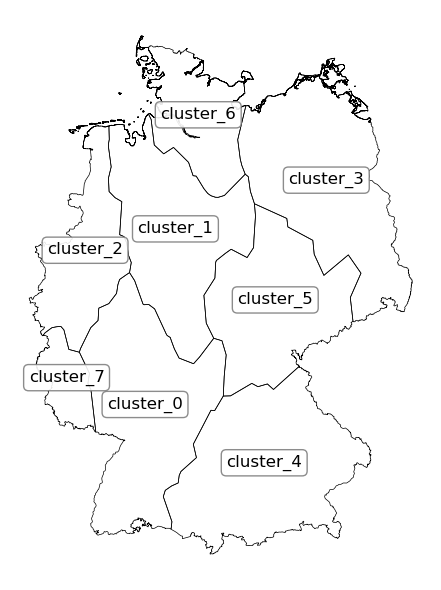

In [34]:
fig, ax = fn.plotLocations(locFilePath, plotLocNames=True, indexColumn="index")

### Sources and Sink

Show optimization summary

In [35]:
esM.getOptimizationSummary("SourceSinkModel", outputLevel=2)

cluster_0  \
Component                    Property         Unit                                     
Biogas purchase              NPVcontribution  [1e9 Euro]                    0.264223   
                             TAC              [1e9 Euro/a]                  0.264223   
                             commodCosts      [1e9 Euro/a]                  0.264223   
                             operation        [GW$_{biogas,LHV}$*h]      4884.879301   
                             operation_annual [GW$_{biogas,LHV}$*h/a]    4884.879301   
Electricity demand           operation        [GW$_{el}$*h]            133963.451433   
                             operation_annual [GW$_{el}$*h/a]          133963.451433   
Existing run-of-river plants NPVcontribution  [1e9 Euro]                    0.144316   
                             TAC              [1e9 Euro/a]                  0.144316   
                             capacity         [GW$_{el}$]                   0.693828   
                             commissioning    [GW$_{el}$]                   0.693828   
                             operation        [GW$_{el}$*h]              3167.329183   
                             operation_annual [GW$_{el}$*h/a]            3167.329183   
                             opexCap          [1e9 Euro/a]                  0.144316   
Hydrogen demand              operation        [GW$_{H_{2},LHV}$*h]      15855.229091   
                             operation_annual [GW$_{H_{2},LHV}$*h/a]    15855.229091   
PV                           NPVcontribution  [1e9 Euro]                    3.200554   
                             TAC              [1e9 Euro/a]                  3.200554   
                             capacity         [GW$_{el}$]                  43.314414   
                             capexCap         [1e9 Euro/a]                  2.637467   
                             commissioning    [GW$_{el}$]                  43.314414   
                             invest           [1e9 Euro]                   28.154369   
                             operation        [GW$_{el}$*h]             40711.706141   
                             operation_annual [GW$_{el}$*h/a]           40711.706141   
                             opexCap          [1e9 Euro/a]                  0.563087   
Wind (offshore)              NPVcontribution  [1e9 Euro]                           0   
                             TAC              [1e9 Euro/a]                         0   
                             capacity         [GW$_{el}$]                        NaN   
                             capexCap         [1e9 Euro/a]                       NaN   
                             commissioning    [GW$_{el}$]                        NaN   
                             invest           [1e9 Euro]                         NaN   
                             operation        [GW$_{el}$*h]                      NaN   
                             operation_annual [GW$_{el}$*h/a]                    NaN   
                             opexCap          [1e9 Euro/a]                       NaN   
Wind (onshore)               NPVcontribution  [1e9 Euro]                         0.0   
                             TAC              [1e9 Euro/a]                       0.0   
                             capacity         [GW$_{el}$]                        0.0   
                             capexCap         [1e9 Euro/a]                       0.0   
                             commissioning    [GW$_{el}$]                        0.0   
                             invest           [1e9 Euro]                         0.0   
                             operation        [GW$_{el}$*h]                      0.0   
                             operation_annual [GW$_{el}$*h/a]                    0.0   
                             opexCap          [1e9 Euro/a]                       0.0   

                                                                          cluster_1  \
Component                  

Plot installed capacities

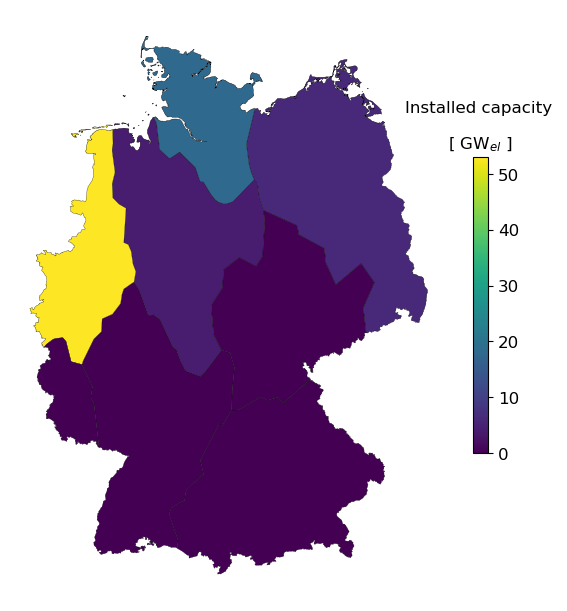

In [36]:
fig, ax = fn.plotLocationalColorMap(
    esM, "Wind (offshore)", locFilePath, "index", perArea=False
)

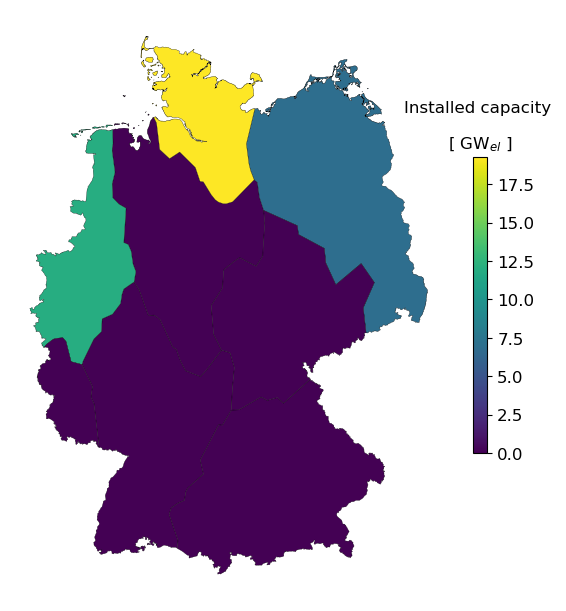

In [37]:
fig, ax = fn.plotLocationalColorMap(
    esM, "Wind (onshore)", locFilePath, "index", perArea=False
)

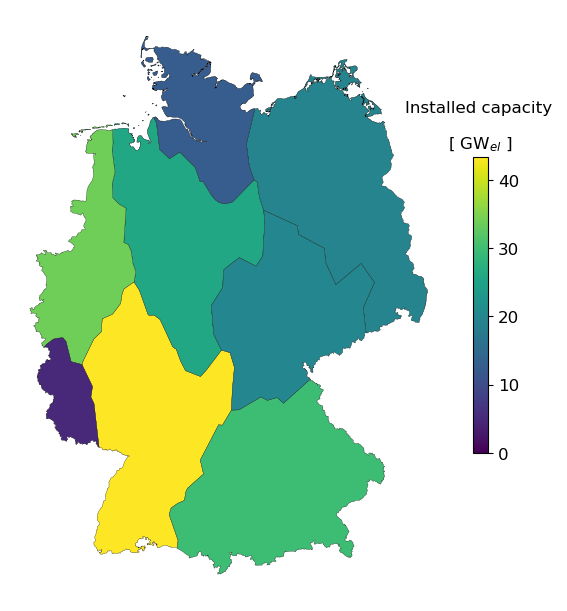

In [38]:
fig, ax = fn.plotLocationalColorMap(esM, "PV", locFilePath, "index", perArea=False)

### Conversion

Show optimization summary

In [39]:
esM.getOptimizationSummary("ConversionModel", outputLevel=2)

cluster_0  \
Component                Property         Unit                            
Electrolyzer             NPVcontribution  [1e9 Euro]            0.22499   
                         TAC              [1e9 Euro/a]          0.22499   
                         capacity         [GW$_{el}$]          2.585654   
                         capexCap         [1e9 Euro/a]         0.192669   
                         commissioning    [GW$_{el}$]          2.585654   
                         invest           [1e9 Euro]           1.292827   
                         operation        [GW$_{el}$*h]    13651.523528   
                         operation_annual [GW$_{el}$*h/a]  13651.523528   
                         opexCap          [1e9 Euro/a]         0.032321   
New CCGT plants (biogas) NPVcontribution  [1e9 Euro]           0.079062   
                         TAC              [1e9 Euro/a]         0.079062   
                         capacity         [GW$_{el}$]          0.966575   
                         capexCap         [1e9 Euro/a]         0.058764   
                         commissioning    [GW$_{el}$]          0.966575   
                         invest           [1e9 Euro]           0.676603   
                         operation        [GW$_{el}$*h]     1692.439543   
                         operation_annual [GW$_{el}$*h/a]   1692.439543   
                         opexCap          [1e9 Euro/a]         0.020298   
hydrogen_exp             NPVcontribution  [1e9 Euro]                0.0   
                         TAC              [1e9 Euro/a]              0.0   
                         capacity         [GW$_{el}$]               0.0   
                         commissioning    [GW$_{el}$]               0.0   
                         operation        [GW$_{el}$*h]             0.0   
                         operation_annual [GW$_{el}$*h/a]           0.0   
                         opexOp           [1e9 Euro/a]              0.0   
hydrogen_imp             NPVcontribution  [1e9 Euro]           0.094487   
                         TAC              [1e9 Euro/a]         0.094487   
                         capacity         [GW$_{el}$]               2.0   
                         commissioning    [GW$_{el}$]               2.0   
                         operation        [GW$_{el}$*h]     6299.162622   
                         operation_annual [GW$_{el}$*h/a]   6299.162622   
                         opexOp           [1e9 Euro/a]         0.094487   

                                                              cluster_1  \
Component                Property         Unit                            
Electrolyzer             NPVcontribution  [1e9 Euro]           0.392291   
                         TAC              [1e9 Euro/a]         0.392291   
                         capacity         [GW$_{el}$]          4.508333   
                         capexCap         [1e9 Euro/a]         0.335937   
                         commissioning    [GW$_{el}$]          4.508333   
                         invest           [1e9 Euro]           2.254166   
                         operation        [GW$_{el}$*h]    15810.686669   
                         operation_annual [GW$_{el}$*h/a]  15810.686669   
                         opexCap          [1e9 Euro/a]         0.056354   
New CCGT plants (biogas) NPVcontribution  [1e9 Euro]           0.232143   
                         TAC              [1e9 Euro/a]         0.232143   
                         capacity         [GW$_{el}$]          2.838068   
                         capexCap         [1e9 Euro/a]         0.172544   
                         commissioning    [GW$_{el}$]          2.838068   
                         invest           [1e9 Euro]           1.986647   
                         operation        [GW$_{el}$*h]     4875.826629   
                         operation_annual [GW$_{el}$*h/a]   4875.826629   
                         opexCap          [1e9 Euro/a]         0.059599   
hydrogen_ex

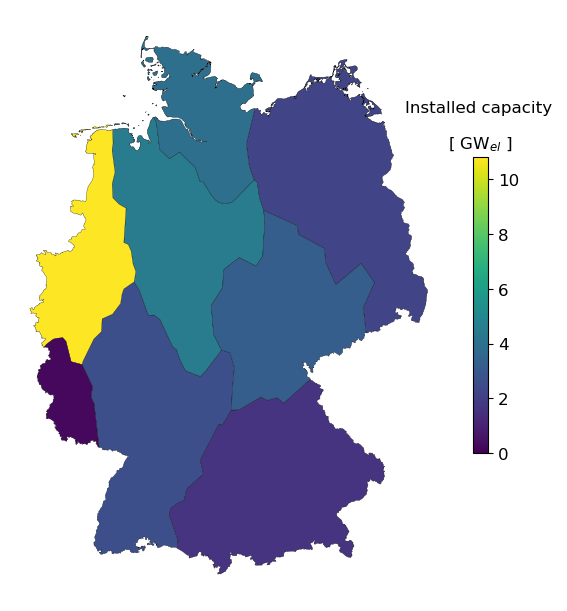

In [40]:
fig, ax = fn.plotLocationalColorMap(
    esM, "Electrolyzer", locFilePath, "index", perArea=False
)

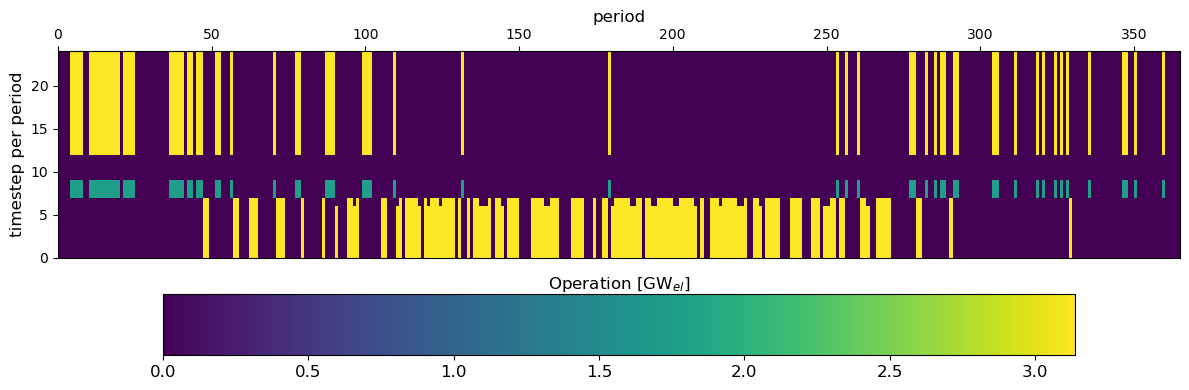

In [41]:
fig, ax = fn.plotOperationColorMap(esM, "New CCGT plants (biogas)", "cluster_2")

## Transmission

Show optimization summary

In [42]:
net_trade_pool_1 = esM.getPoolNetPositions(
    commodity="hydrogen_trade", poolName="DE_hydrogen_pool_1"
)
print("Net Trade in Pool 1:")
print(net_trade_pool_1.values.sum())

net_trade_pool_2 = esM.getPoolNetPositions(
    commodity="hydrogen_trade", poolName="DE_hydrogen_pool_2"
)
print("Net Trade in Pool 2:")
print(net_trade_pool_2.values.sum())

Net Trade in Pool 1:
2.6645352591003757e-15
Net Trade in Pool 2:
2.4868995751603507e-14


In [43]:
net_trade_pool_1

cluster_0   -96.861739
cluster_1     1.285612
cluster_2    94.415080
cluster_3     1.161047
Name: hydrogen_trade_DE_hydrogen_pool_1_net_flow, dtype: float64

Export

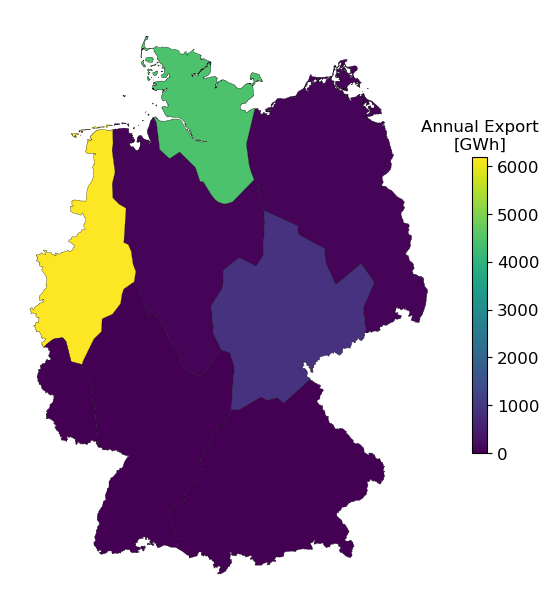

In [44]:
fig, ax = fn.plotLocationalColorMap(
    esM,
    "hydrogen_exp",
    locFilePath,
    "index",
    perArea=False,
    variableName="operationVariablesOptimum",
    doSum=True,
    zlabel="Annual Export [GWh]",
)

Import

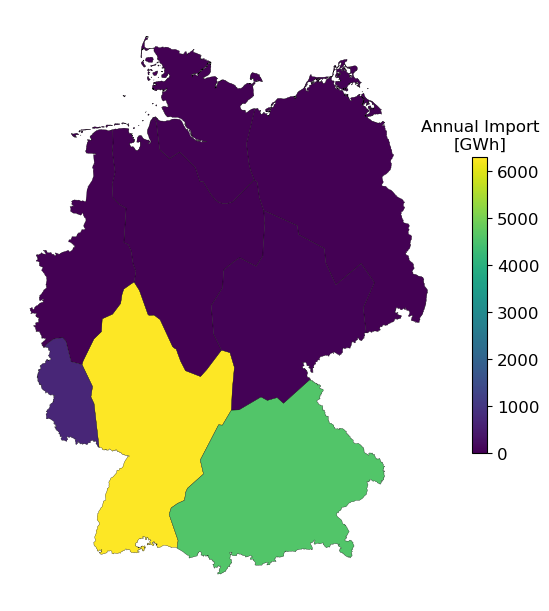

In [45]:
fig, ax = fn.plotLocationalColorMap(
    esM,
    "hydrogen_imp",
    locFilePath,
    "index",
    perArea=False,
    variableName="operationVariablesOptimum",
    doSum=True,
    zlabel="Annual Import [GWh]",
)